# 🏃 UCI-HAR: CNN + GRU + Gated Attention Mechanism
### Human Activity Recognition — No Data Leakage | Full Evaluation

**Architecture:** Raw inertial signals → CNN (local feature extraction) → GRU (temporal modeling) → Gated Attention → Classification

**Data Leakage Prevention:** Train/Val/Test splits are done at the **subject level** — no subject appears in more than one split.

**Activities:** WALKING · WALKING_UPSTAIRS · WALKING_DOWNSTAIRS · SITTING · STANDING · LAYING

## 📦 Step 1 — Install & Import Libraries

In [ ]:
!pip install -q scikit-learn matplotlib seaborn tensorflow

import os, zipfile, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 📂 Step 2 — Upload & Extract Dataset
Upload your `UCI-HAR.zip` when prompted.

In [ ]:
from google.colab import files

print('Please upload UCI-HAR.zip ...')
uploaded = files.upload()

zip_name    = list(uploaded.keys())[0]
extract_dir = '/content/UCI_HAR'

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(extract_dir)

def find_dataset_root(base):
    for root, dirs, files_list in os.walk(base):
        if 'activity_labels.txt' in files_list:
            return root
    raise FileNotFoundError('activity_labels.txt not found — check zip structure.')

DATASET_PATH = find_dataset_root(extract_dir)
print(f'Dataset root: {DATASET_PATH}')
print(os.listdir(DATASET_PATH))

Please upload UCI-HAR.zip ...


Saving UCI-HAR.zip to UCI-HAR.zip
Dataset root: /content/UCI_HAR/UCI-HAR/UCI HAR Dataset
['.DS_Store', 'features_info.txt', 'test', 'activity_labels.txt', 'README.txt', 'train', '__MACOSX', 'features.txt']


## 🔬 Step 3 — Load Raw Inertial Signals (9 Channels × 128 Timesteps)
We use **raw signals** (not pre-computed features) so the CNN can learn its own feature extraction.

In [ ]:
SIGNAL_NAMES = [
    'body_acc_x', 'body_acc_y', 'body_acc_z',
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
    'total_acc_x', 'total_acc_y', 'total_acc_z'
]

ACTIVITY_LABELS = {
    1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING', 5: 'STANDING', 6: 'LAYING'
}
N_CLASSES   = 6
N_TIMESTEPS = 128
N_CHANNELS  = 9

def load_signals(split):
    sig_dir = os.path.join(DATASET_PATH, split, 'Inertial Signals')
    data = []
    for name in SIGNAL_NAMES:
        fpath = os.path.join(sig_dir, f'{name}_{split}.txt')
        arr = pd.read_csv(fpath, header=None, sep='\s+').values
        data.append(arr)
    return np.stack(data, axis=2).astype(np.float32)  # (N, 128, 9)

def load_labels(split):
    fpath = os.path.join(DATASET_PATH, split, f'y_{split}.txt')
    return pd.read_csv(fpath, header=None).values.flatten() - 1  # 0-indexed

def load_subjects(split):
    fpath = os.path.join(DATASET_PATH, split, f'subject_{split}.txt')
    return pd.read_csv(fpath, header=None).values.flatten()

print('Loading train signals ...')
X_train_full = load_signals('train')
y_train_full = load_labels('train')
subj_train   = load_subjects('train')

print('Loading test signals ...')
X_test    = load_signals('test')
y_test    = load_labels('test')
subj_test = load_subjects('test')

print(f'Train: {X_train_full.shape}, labels: {y_train_full.shape}')
print(f'Test : {X_test.shape},  labels: {y_test.shape}')
print(f'Train subjects: {sorted(np.unique(subj_train))}')
print(f'Test  subjects: {sorted(np.unique(subj_test))}')

Loading train signals ...


<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_8520/1285066398.py:20: SyntaxWarning: invalid escape sequence '\s'
  arr = pd.read_csv(fpath, header=None, sep='\s+').values


Loading test signals ...
Train: (7352, 128, 9), labels: (7352,)
Test : (2947, 128, 9),  labels: (2947,)
Train subjects: [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Test  subjects: [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]


## 🛡️ Step 4 — Subject-Level Split (No Data Leakage)
Validation subjects are carved out from the training pool. No subject appears in more than one split.

In [ ]:
train_subjects = sorted(np.unique(subj_train))
test_subjects  = sorted(np.unique(subj_test))

overlap = set(train_subjects) & set(test_subjects)
assert len(overlap) == 0, f'DATA LEAK: subjects {overlap} appear in both train and test!'
print(f'✅ No overlap between train ({len(train_subjects)} subj) and test ({len(test_subjects)} subj)')

np.random.seed(SEED)
val_subjects = np.random.choice(train_subjects, size=4, replace=False).tolist()
tr_subjects  = [s for s in train_subjects if s not in val_subjects]

print(f'Train subjects ({len(tr_subjects)}): {tr_subjects}')
print(f'Val   subjects ({len(val_subjects)}): {val_subjects}')
print(f'Test  subjects ({len(test_subjects)}): {test_subjects}')

tr_mask  = np.isin(subj_train, tr_subjects)
val_mask = np.isin(subj_train, val_subjects)

X_train = X_train_full[tr_mask]
y_train = y_train_full[tr_mask]
X_val   = X_train_full[val_mask]
y_val   = y_train_full[val_mask]

print(f'\nFinal splits:')
print(f'  Train: {X_train.shape}')
print(f'  Val  : {X_val.shape}')
print(f'  Test : {X_test.shape}')

✅ No overlap between train (21 subj) and test (9 subj)
Train subjects (17): [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(26), np.int64(28), np.int64(29), np.int64(30)]
Val   subjects (4): [1, 27, 25, 3]
Test  subjects (9): [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]

Final splits:
  Train: (5879, 128, 9)
  Val  : (1473, 128, 9)
  Test : (2947, 128, 9)


## 📊 Step 5 — Normalize (Per-Channel, Fit on Train Only)

In [ ]:
train_mean = X_train.mean(axis=(0, 1), keepdims=True)  # (1, 1, 9)
train_std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std

y_train_cat = to_categorical(y_train, N_CLASSES)
y_val_cat   = to_categorical(y_val,   N_CLASSES)
y_test_cat  = to_categorical(y_test,  N_CLASSES)

print('Normalization done (fit on train only — no leakage).')
print(f'X_train range: [{X_train.min():.3f}, {X_train.max():.3f}]')
print(f'X_val   range: [{X_val.min():.3f},   {X_val.max():.3f}]')
print(f'X_test  range: [{X_test.min():.3f},  {X_test.max():.3f}]')

Normalization done (fit on train only — no leakage).
X_train range: [-15.315, 14.734]
X_val   range: [-8.654,   7.210]
X_test  range: [-10.208,  8.894]


## 🔍 Step 6 — Exploratory Data Analysis

/tmp/ipykernel_8520/2264698950.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(activity_names, rotation=30, ha='right', fontsize=9)
/tmp/ipykernel_8520/2264698950.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(activity_names, rotation=30, ha='right', fontsize=9)
/tmp/ipykernel_8520/2264698950.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(activity_names, rotation=30, ha='right', fontsize=9)


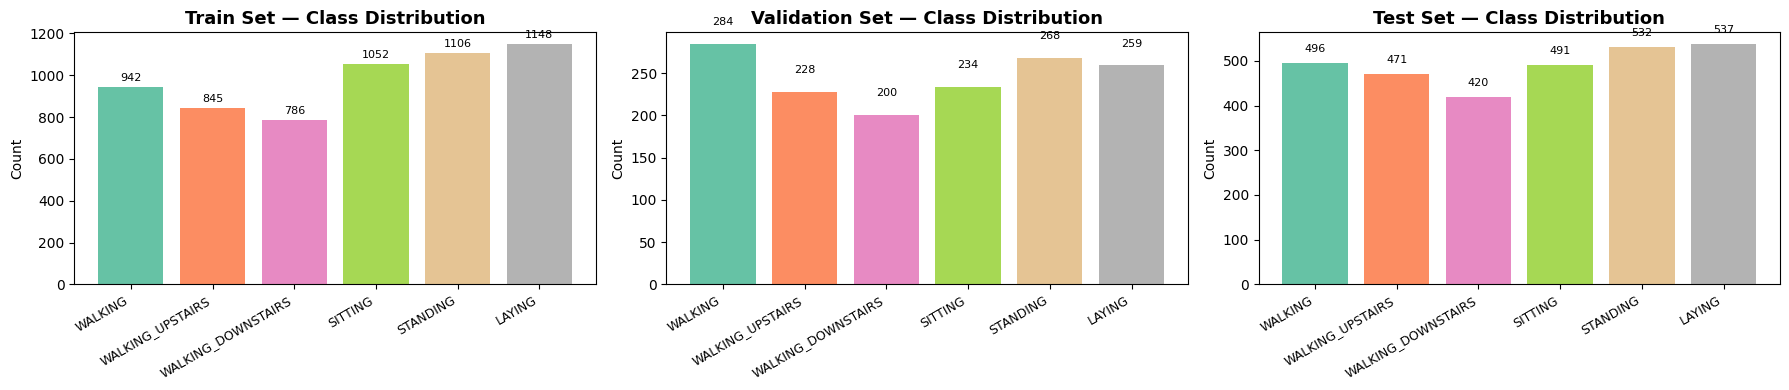

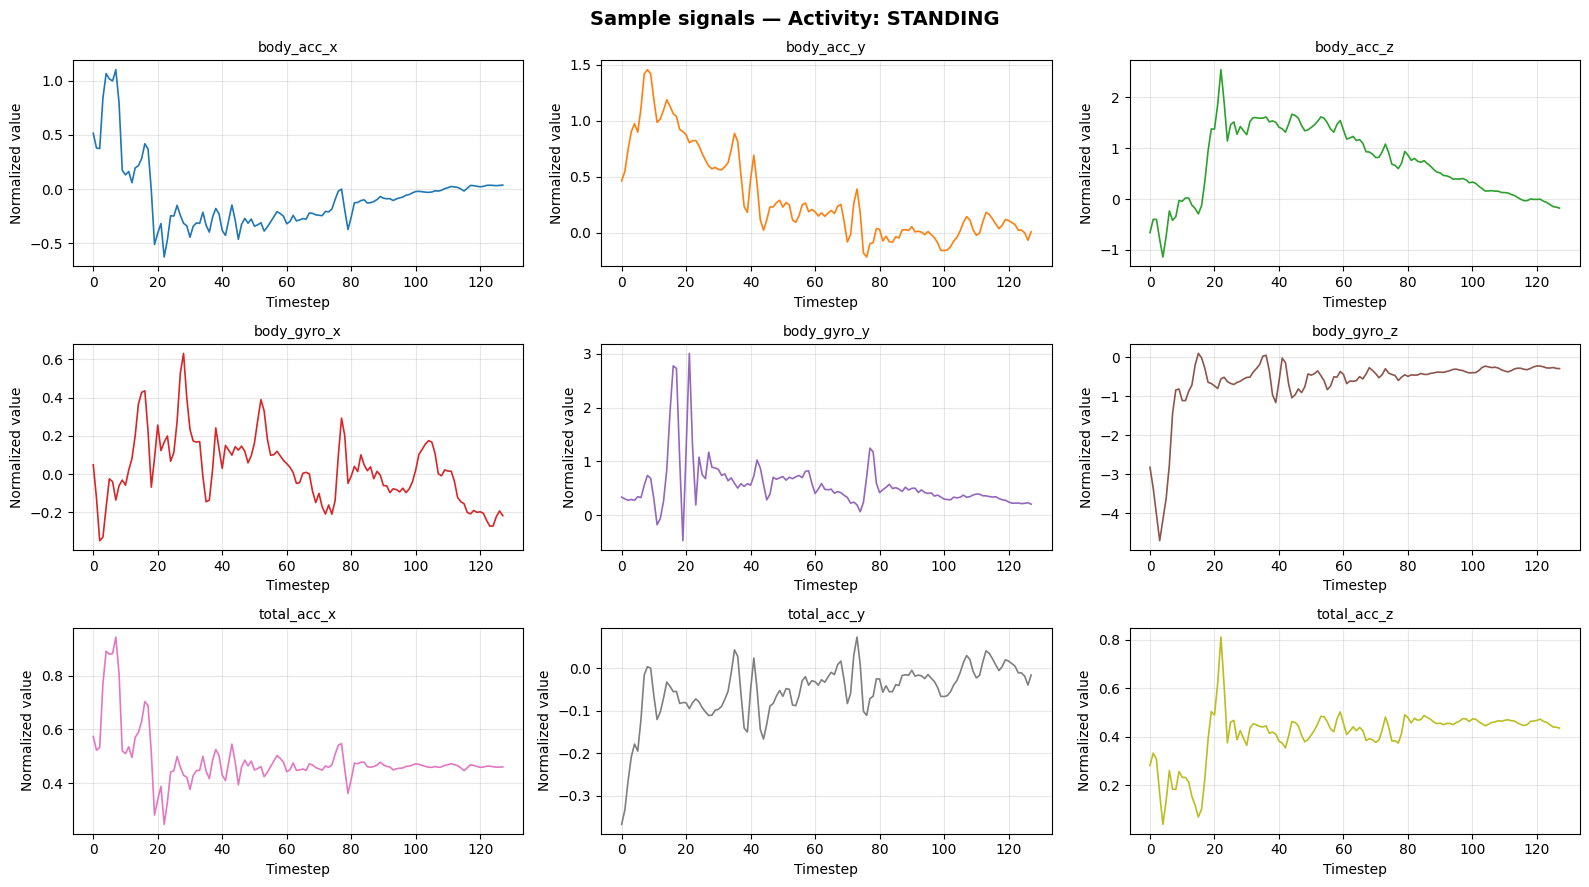

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
activity_names = [ACTIVITY_LABELS[i+1] for i in range(N_CLASSES)]

for ax, (y_split, title) in zip(axes, [
    (y_train, 'Train'), (y_val, 'Validation'), (y_test, 'Test')
]):
    counts = [np.sum(y_split == i) for i in range(N_CLASSES)]
    bars = ax.bar(activity_names, counts, color=plt.cm.Set2(np.linspace(0, 1, 6)))
    ax.set_title(f'{title} Set — Class Distribution', fontsize=13, fontweight='bold')
    ax.set_xticklabels(activity_names, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Count')
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+20,
                str(c), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(16, 9))
sample_idx = 0
for i, (ax, name) in enumerate(zip(axes.flatten(), SIGNAL_NAMES)):
    ax.plot(X_train[sample_idx, :, i], color=f'C{i}', linewidth=1.2)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Normalized value')
    ax.grid(alpha=0.3)

activity = ACTIVITY_LABELS[y_train[sample_idx]+1]
fig.suptitle(f'Sample signals — Activity: {activity}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('signal_sample.png', dpi=120, bbox_inches='tight')
plt.show()

## 🏗️ Step 7 — CNN + GRU + Gated Attention Architecture

```
Input (128, 9)
   │
   ├─ Conv1D (64 filters, k=3) → BN → ReLU
   ├─ Conv1D (64 filters, k=3) → BN → ReLU → MaxPool
   ├─ Conv1D (128 filters, k=3) → BN → ReLU
   ├─ Conv1D (128 filters, k=3) → BN → ReLU → MaxPool
   │
   ├─ Bidirectional GRU (128 units, return_sequences=True)
   ├─ Bidirectional GRU (64 units,  return_sequences=True)
   │
   ├─ Gated Attention Mechanism
   │     ├─ score = tanh(W_h · h)          — content gate
   │     ├─ gate  = sigmoid(W_g · h)       — information gate
   │     └─ α = softmax(score ⊙ gate)      — gated attention weights
   │
   ├─ Dropout → Dense(128) → BN → ReLU
   └─ Dense(6, softmax)
```

> **Fix note:** `add_weight()` in Keras 3 requires `shape` as the **first keyword argument**. Passing the name as a positional arg caused the `TypeError: multiple values for argument 'shape'` error.

In [ ]:
class GatedAttention(layers.Layer):
    """
    Gated Attention Mechanism.
    Given hidden states H of shape (batch, T, d):
      score   = tanh(H @ W_h)           — content relevance
      gate    = sigmoid(H @ W_g)        — information gate
      alpha   = softmax(score * gate)   — gated attention weights
      context = sum_t(alpha_t * H_t)    — weighted context vector
    """
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        d = input_shape[-1]
        # FIX: In Keras 3, add_weight() takes shape as the FIRST keyword arg.
        # Passing the name as a positional arg clashes with shape → TypeError.
        self.W_h = self.add_weight(
            shape=(d, self.units), name='W_h',
            initializer='glorot_uniform', trainable=True)
        self.W_g = self.add_weight(
            shape=(d, self.units), name='W_g',
            initializer='glorot_uniform', trainable=True)
        self.v   = self.add_weight(
            shape=(self.units, 1), name='v',
            initializer='glorot_uniform', trainable=True)
        super().build(input_shape)

    def call(self, H):
        # H: (batch, T, d)
        score   = tf.tanh(tf.matmul(H, self.W_h))     # (batch, T, units)
        gate    = tf.sigmoid(tf.matmul(H, self.W_g))  # (batch, T, units)
        gated   = score * gate                          # element-wise gating
        e       = tf.matmul(gated, self.v)             # (batch, T, 1)
        attn_w  = tf.nn.softmax(e, axis=1)             # (batch, T, 1)
        context = tf.reduce_sum(attn_w * H, axis=1)   # (batch, d)
        return context, tf.squeeze(attn_w, axis=-1)    # context, (batch, T)

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config


def build_model(input_shape=(N_TIMESTEPS, N_CHANNELS), n_classes=N_CLASSES,
                gru_units_1=128, gru_units_2=64, attn_units=64,
                dropout_rate=0.4, dense_units=128):

    inp = layers.Input(shape=input_shape, name='input')

    # ── CNN Block 1 ──────────────────────────────────────────────
    x = layers.Conv1D(64, kernel_size=3, padding='same', name='conv1')(inp)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv1D(64, kernel_size=3, padding='same', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool1')(x)   # 128→64
    x = layers.Dropout(0.2)(x)

    # ── CNN Block 2 ──────────────────────────────────────────────
    x = layers.Conv1D(128, kernel_size=3, padding='same', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv1D(128, kernel_size=3, padding='same', name='conv4')(x)
    x = layers.BatchNormalization(name='bn4')(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool2')(x)   # 64→32
    x = layers.Dropout(0.2)(x)

    # ── Bidirectional GRU ─────────────────────────────────────────
    x = layers.Bidirectional(
            layers.GRU(gru_units_1, return_sequences=True,
                       dropout=0.2, recurrent_dropout=0.0),
            name='bigru_1')(x)
    x = layers.Bidirectional(
            layers.GRU(gru_units_2, return_sequences=True,
                       dropout=0.2, recurrent_dropout=0.0),
            name='bigru_2')(x)

    # ── Gated Attention ───────────────────────────────────────────
    # Returns (context, attn_weights) — we use only context for classification
    context, _ = GatedAttention(units=attn_units, name='gated_attention')(x)

    # ── Classifier Head ───────────────────────────────────────────
    x = layers.Dropout(dropout_rate)(context)
    x = layers.Dense(dense_units, name='fc1')(x)
    x = layers.BatchNormalization(name='bn5')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate / 2)(x)
    out = layers.Dense(n_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inp, outputs=out, name='CNN_GRU_GatedAttention')
    return model


model = build_model()
model.summary()

Model: "CNN_GRU_GatedAttention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 128, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 128, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 128, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 128, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 64, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv1D)                  │ (None, 64, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 64, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru_1 (Bidirectional)         │ (None, 32, 256)        │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru_2 (Bidirectional)         │ (None, 32, 128)        │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gated_attention                 │ [(None, 128), (None,   │        16,448 │
│ (GatedAttention)                │ 32)]                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 445,702 (1.70 MB)

 Trainable params: 444,678 (1.70 MB)

 Non-trainable params: 1,024 (4.00 KB)

## ⚙️ Step 8 — Compile & Configure Training

In [ ]:
EPOCHS     = 80
BATCH_SIZE = 64
LR_INIT    = 1e-3

lr_schedule = keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=LR_INIT,
    first_decay_steps=20,
    t_mul=2.0,
    m_mul=0.85
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# NOTE: ReduceLROnPlateau is intentionally excluded — it cannot coexist with
# a LearningRateSchedule (CosineDecayRestarts already handles LR annealing).
cb_list = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=15,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_model.weights.h5', monitor='val_accuracy',
        save_best_only=True, save_weights_only=True, verbose=0
    ),
]

print(f'Training config: epochs={EPOCHS}, batch={BATCH_SIZE}, LR={LR_INIT}')

Training config: epochs=80, batch=64, LR=0.001


## 🚀 Step 9 — Train the Model

In [ ]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb_list,
    verbose=1
)

print('\n✅ Training complete!')
best_val_acc = max(history.history['val_accuracy'])
print(f'Best validation accuracy: {best_val_acc:.4f}')

Epoch 1/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.7642 - loss: 0.6048 - val_accuracy: 0.7787 - val_loss: 0.7318
Epoch 2/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9246 - loss: 0.2220 - val_accuracy: 0.9328 - val_loss: 0.2103
Epoch 3/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9342 - loss: 0.1730 - val_accuracy: 0.9606 - val_loss: 0.1009
Epoch 4/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9372 - loss: 0.1643 - val_accuracy: 0.9633 - val_loss: 0.0966
Epoch 5/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9408 - loss: 0.1469 - val_accuracy: 0.9511 - val_loss: 0.1453
Epoch 6/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9444 - loss: 0.1384 - val_accuracy: 0.9701 - val_loss: 0.0992
Epoch 7/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9430 - loss: 0.1330 - val_accuracy: 0.9593 - val_loss: 0.1448
Epoch 8/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9427 - loss: 0.1407 - val_accuracy: 0.9647 - 

## 📈 Step 10 — Training Curves








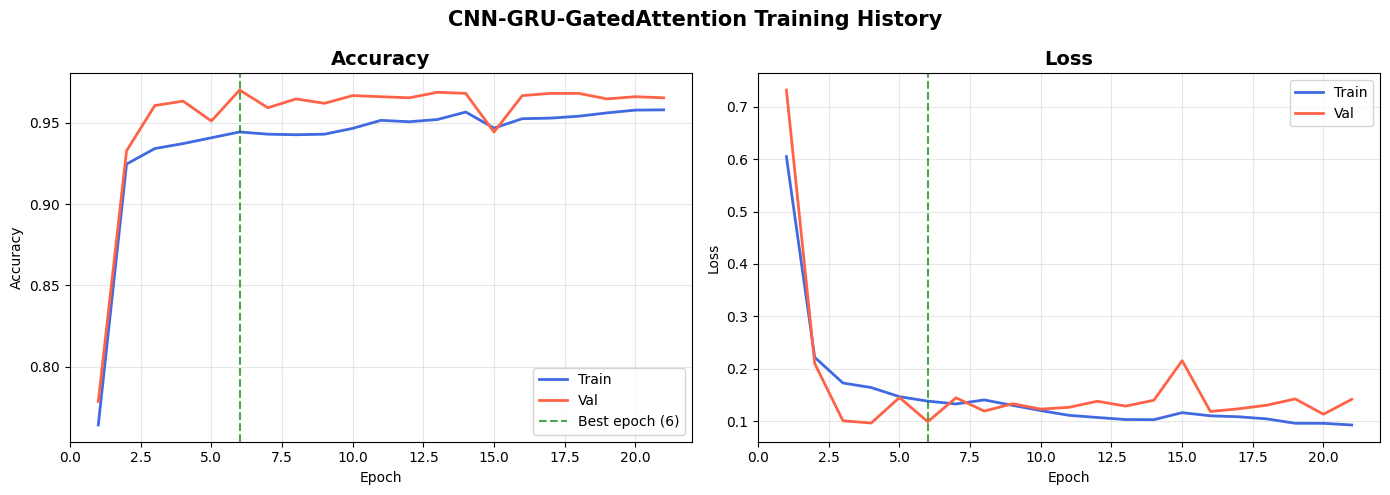

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history.history['accuracy']) + 1)

ax1.plot(epochs_range, history.history['accuracy'],     label='Train', color='royalblue', linewidth=2)
ax1.plot(epochs_range, history.history['val_accuracy'], label='Val',   color='tomato',    linewidth=2)
best_ep = np.argmax(history.history['val_accuracy']) + 1
ax1.axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Best epoch ({best_ep})')
ax1.set_title('Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_range, history.history['loss'],     label='Train', color='royalblue', linewidth=2)
ax2.plot(epochs_range, history.history['val_loss'], label='Val',   color='tomato',    linewidth=2)
ax2.axvline(best_ep, color='green', linestyle='--', alpha=0.7)
ax2.set_title('Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('CNN-GRU-GatedAttention Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 🎯 Step 11 — Evaluate on Test Set

In [ ]:
# Restore best weights — EarlyStopping(restore_best_weights=True) already does
# this in-memory. The file load is a safety fallback only.
CKPT_PATH = 'best_model.weights.h5'
if os.path.exists(CKPT_PATH):
    model.load_weights(CKPT_PATH)
    print(f'✅ Loaded best weights from {CKPT_PATH}')
else:
    print('ℹ️  Checkpoint file not found — using in-memory best weights (restore_best_weights=True).')

y_pred_proba = model.predict(X_test,  batch_size=BATCH_SIZE, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

y_train_pred = np.argmax(model.predict(X_train, batch_size=BATCH_SIZE, verbose=0), axis=1)
y_val_pred   = np.argmax(model.predict(X_val,   batch_size=BATCH_SIZE, verbose=0), axis=1)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc   = accuracy_score(y_val,   y_val_pred)
test_acc  = accuracy_score(y_test,  y_pred)

train_f1 = f1_score(y_train, y_train_pred, average='weighted')
val_f1   = f1_score(y_val,   y_val_pred,   average='weighted')
test_f1  = f1_score(y_test,  y_pred,       average='weighted')

print('='*55)
print(f'{"Split":<12} {"Accuracy":>10} {"Weighted F1":>14}')
print('-'*55)
print(f'{"Train":<12} {train_acc:>10.4f} {train_f1:>14.4f}')
print(f'{"Validation":<12} {val_acc:>10.4f} {val_f1:>14.4f}')
print(f'{"Test":<12} {test_acc:>10.4f} {test_f1:>14.4f}')
print('='*55)

✅ Loaded best weights from best_model.weights.h5
Split          Accuracy    Weighted F1
-------------------------------------------------------
Train            0.9505         0.9504
Validation       0.9701         0.9702
Test             0.9298         0.9298


## 🔢 Step 12 — Classification Report

In [ ]:
print('\n── TEST SET — CLASSIFICATION REPORT ──\n')
print(classification_report(
    y_test, y_pred,
    target_names=list(ACTIVITY_LABELS.values()),
    digits=4
))


── TEST SET — CLASSIFICATION REPORT ──

                    precision    recall  f1-score   support

           WALKING     1.0000    0.9435    0.9710       496
  WALKING_UPSTAIRS     0.9342    0.9639    0.9488       471
WALKING_DOWNSTAIRS     0.9052    1.0000    0.9502       420
           SITTING     0.8648    0.8595    0.8621       491
          STANDING     0.8859    0.8759    0.8809       532
            LAYING     0.9903    0.9497    0.9696       537

          accuracy                         0.9298      2947
         macro avg     0.9301    0.9321    0.9304      2947
      weighted avg     0.9311    0.9298    0.9298      2947



## 🟦 Step 13 — Confusion Matrix

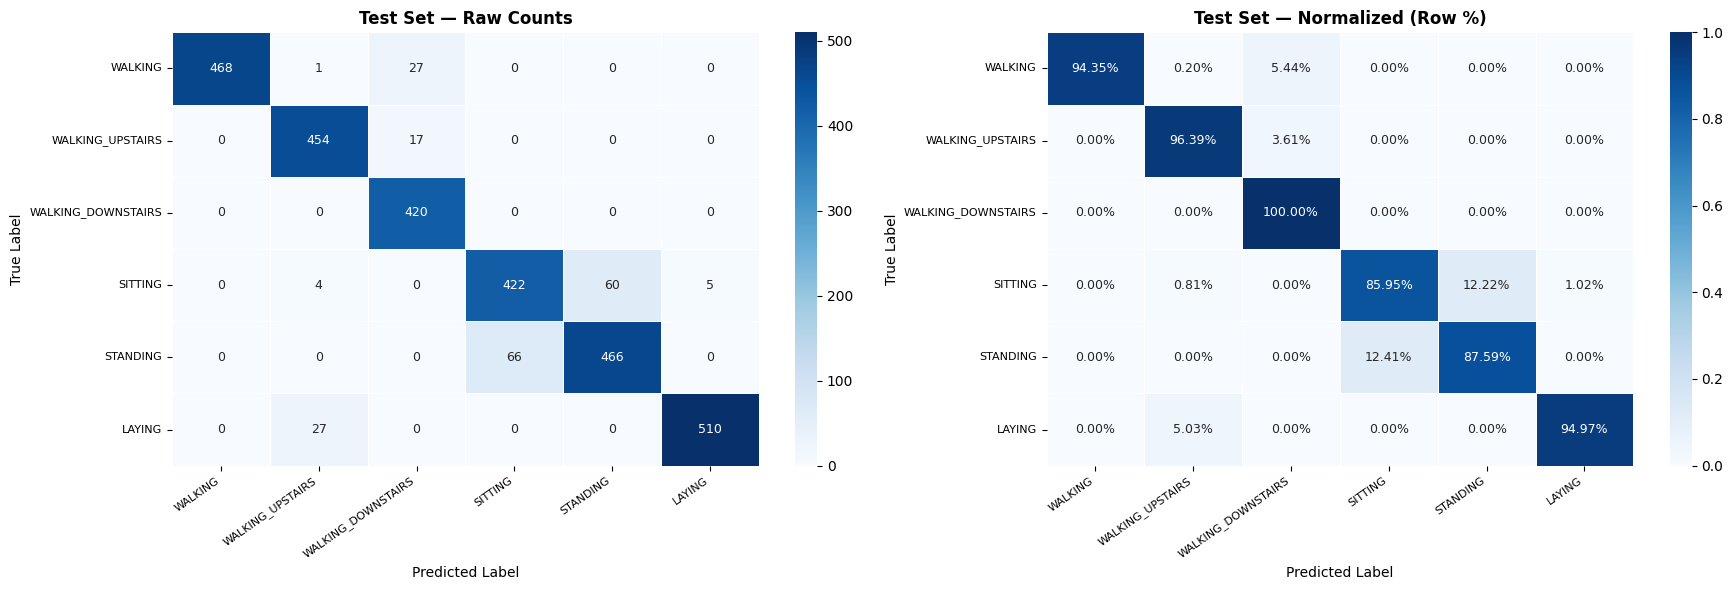

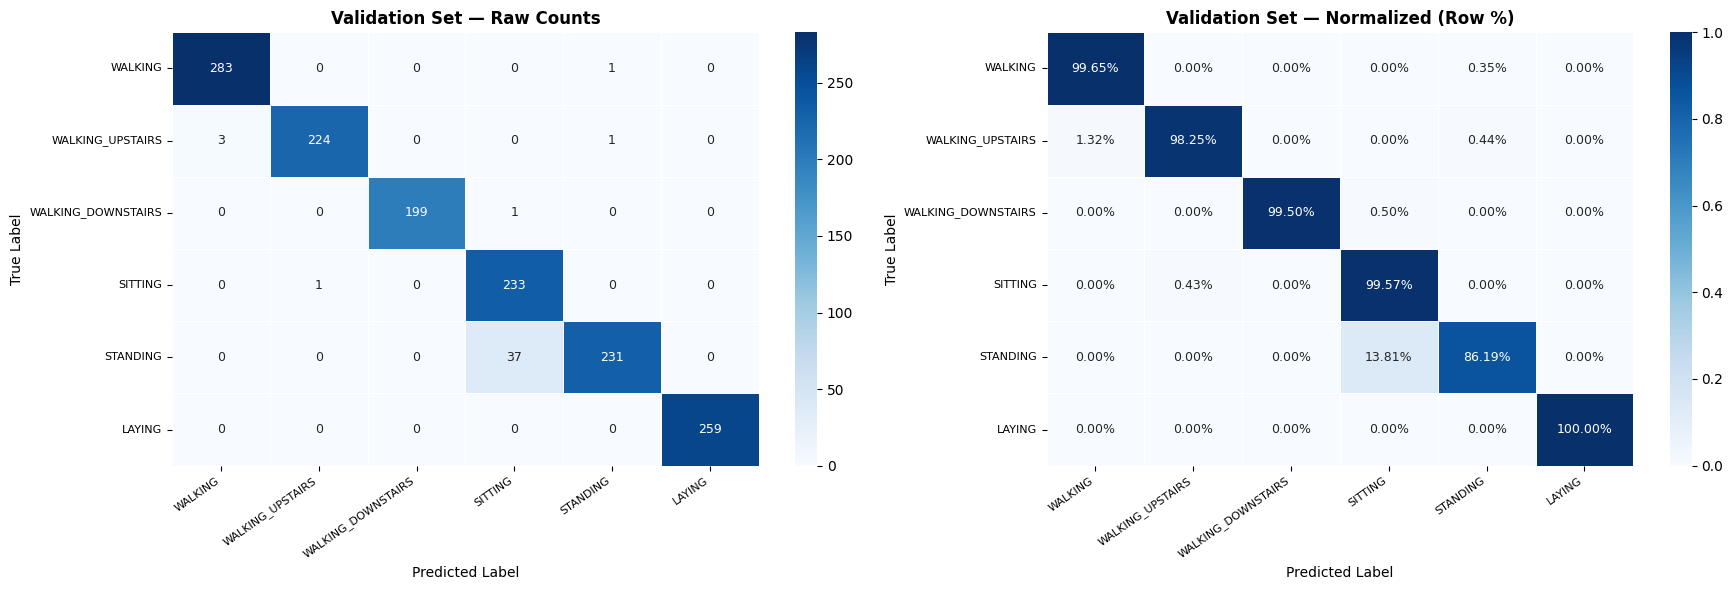

In [ ]:
def plot_confusion_matrix(y_true, y_pred_labels, title, save_path):
    cm   = confusion_matrix(y_true, y_pred_labels)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    labels = list(ACTIVITY_LABELS.values())

    for ax, data, fmt, ttl in zip(
        axes,
        [cm, cm_n],
        ['d', '.2%'],
        ['Raw Counts', 'Normalized (Row %)'],
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=labels, yticklabels=labels,
                    linewidths=0.5, ax=ax, annot_kws={'size': 9})
        ax.set_title(f'{title} — {ttl}', fontsize=12, fontweight='bold')
        ax.set_ylabel('True Label', fontsize=10)
        ax.set_xlabel('Predicted Label', fontsize=10)
        ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
        ax.set_yticklabels(labels, rotation=0, fontsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion_matrix(y_test, y_pred,       'Test Set',       'confusion_matrix_test.png')
plot_confusion_matrix(y_val,  y_val_pred,   'Validation Set', 'confusion_matrix_val.png')

## 📉 Step 14 — ROC Curves (One-vs-Rest)

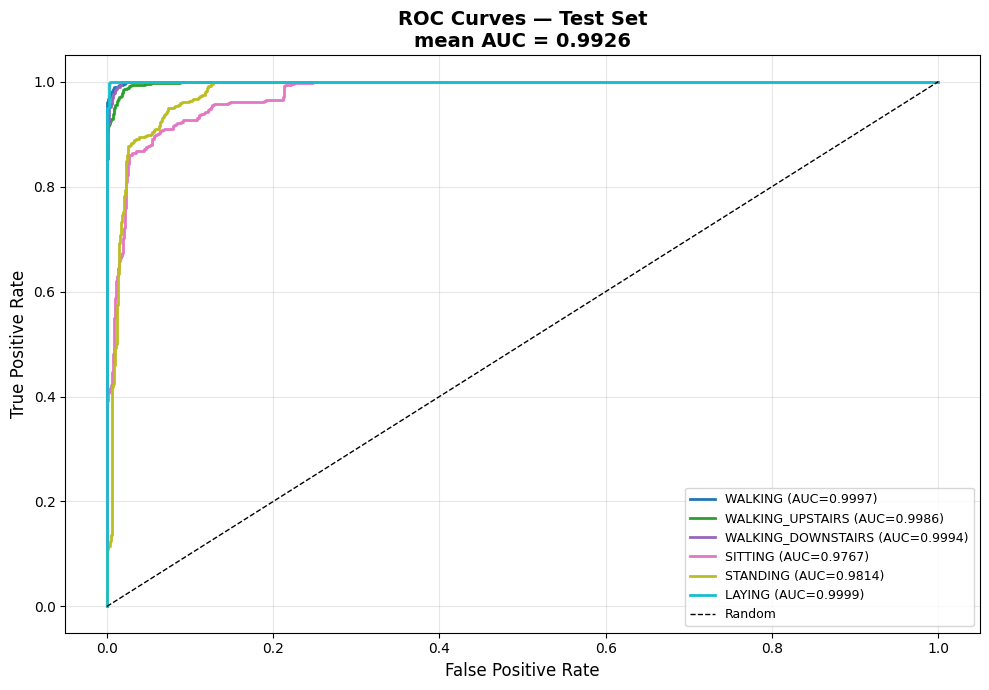

Per-class AUC scores:
  WALKING                   AUC = 0.9997
  WALKING_UPSTAIRS          AUC = 0.9986
  WALKING_DOWNSTAIRS        AUC = 0.9994
  SITTING                   AUC = 0.9767
  STANDING                  AUC = 0.9814
  LAYING                    AUC = 0.9999


In [ ]:
y_test_bin = label_binarize(y_test, classes=list(range(N_CLASSES)))

fig, ax = plt.subplots(figsize=(10, 7))
colors  = plt.cm.tab10(np.linspace(0, 1, N_CLASSES))

auc_scores = []
for i, (name, color) in enumerate(zip(ACTIVITY_LABELS.values(), colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC={roc_auc:.4f})')

ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curves — Test Set\nmean AUC = {np.mean(auc_scores):.4f}',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('Per-class AUC scores:')
for name, score in zip(ACTIVITY_LABELS.values(), auc_scores):
    print(f'  {name:<25} AUC = {score:.4f}')

## 👁️ Step 15 — Gated Attention Weights Visualization

> **Fix note:** `alpha` was used as both the attention weight variable **and** matplotlib's transparency kwarg in `ax2.bar()`, causing a silent conflict. Renamed the attention variable to `attn_w` throughout.

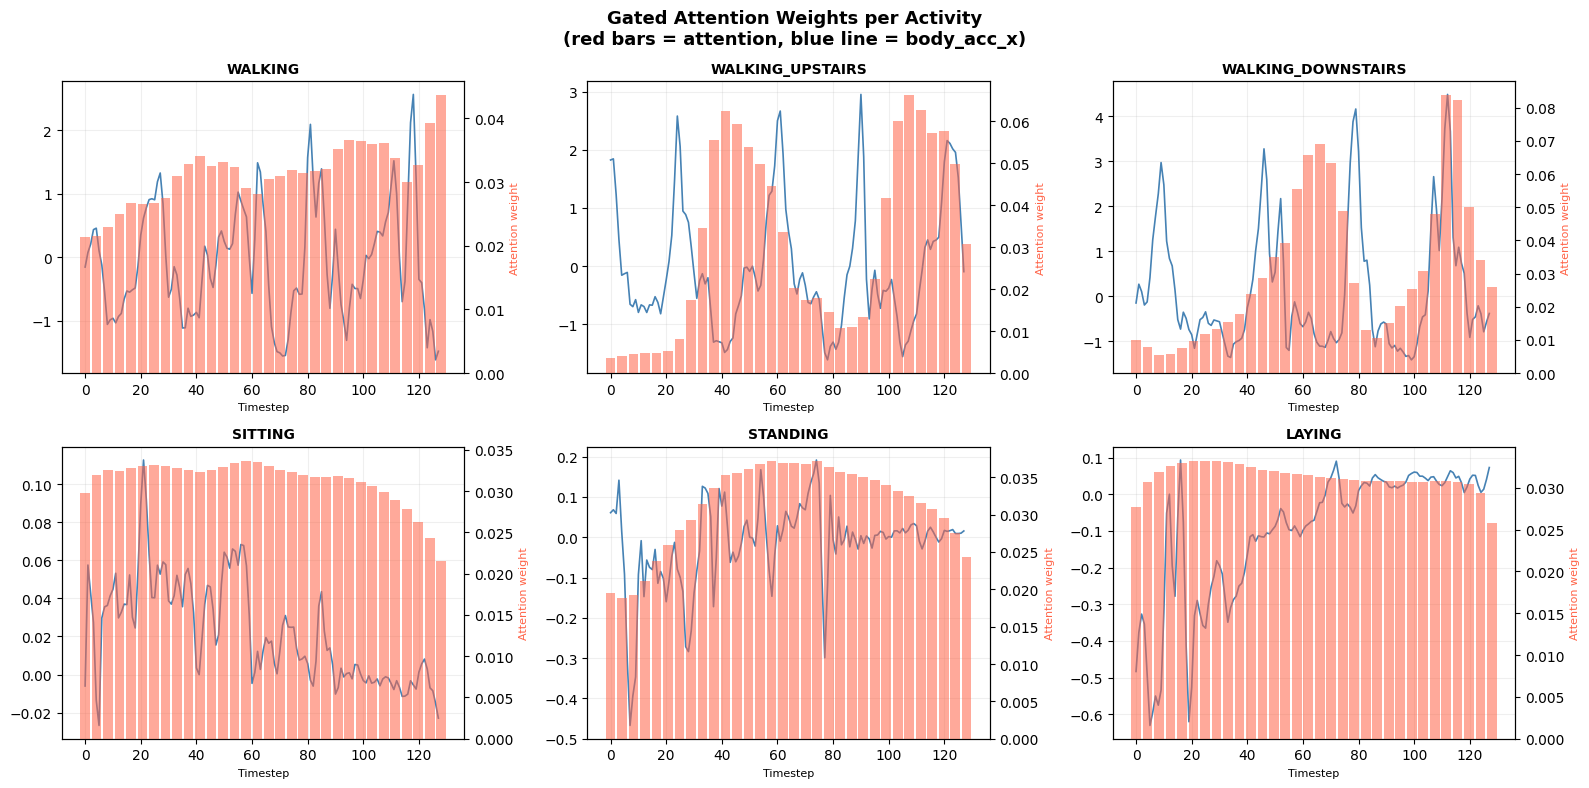

In [ ]:
# Build a separate model that outputs the attention weights
# We re-run the GRU output through the attention layer explicitly.
gru_output  = model.get_layer('bigru_2').output
attn_layer  = model.get_layer('gated_attention')
_, attn_out = attn_layer(gru_output)   # attn_out shape: (batch, T_reduced)

attn_model = Model(inputs=model.input, outputs=attn_out)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, act_idx in zip(axes.flatten(), range(N_CLASSES)):
    idx    = np.where(y_test == act_idx)[0][0]
    sample = X_test[idx:idx+1]              # (1, 128, 9)

    # attn_w: (T_reduced,)  — renamed from 'alpha' to avoid matplotlib kwarg clash
    attn_w    = attn_model.predict(sample, verbose=0)[0]
    T_reduced = len(attn_w)
    x_ticks   = np.linspace(0, N_TIMESTEPS, T_reduced)

    raw_signal = sample[0, :, 0]   # body_acc_x
    ax2 = ax.twinx()
    ax.plot(raw_signal, color='steelblue', linewidth=1.2, label='body_acc_x')
    # Use 'alpha' only as the matplotlib transparency kwarg (0.55), not as a variable
    ax2.bar(x_ticks, attn_w, width=3.5, color='tomato', alpha=0.55, label='Attention')
    ax2.set_ylabel('Attention weight', color='tomato', fontsize=8)
    ax.set_title(f'{ACTIVITY_LABELS[act_idx+1]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Timestep', fontsize=8)
    ax.grid(alpha=0.2)

fig.suptitle(
    'Gated Attention Weights per Activity\n(red bars = attention, blue line = body_acc_x)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('attention_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Step 16 — Per-Class Precision / Recall / F1 Bar Chart

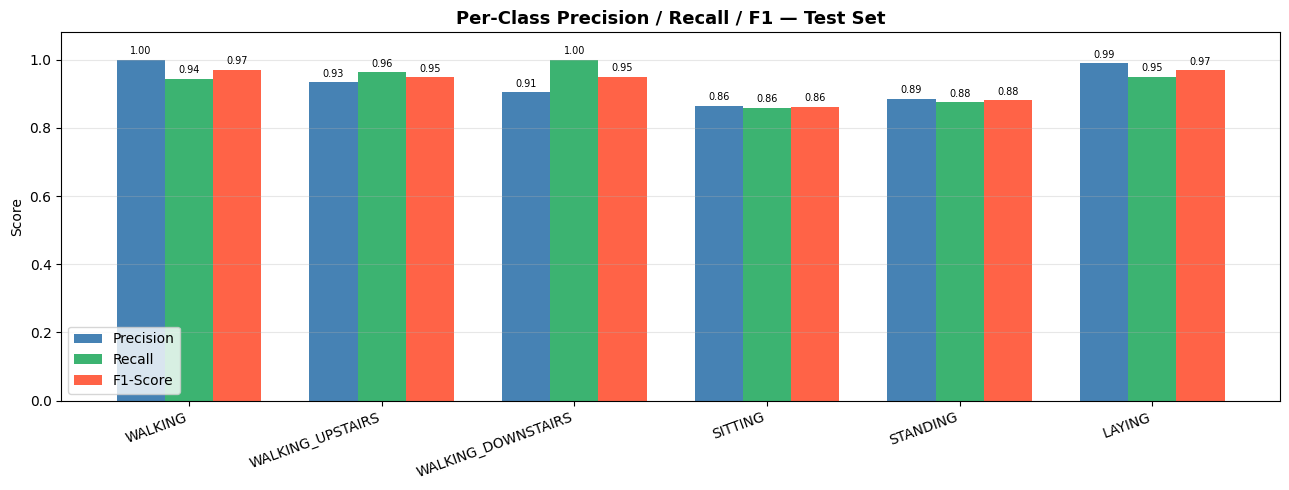

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, average=None, labels=list(range(N_CLASSES))
)

x     = np.arange(N_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, precision, width, label='Precision', color='steelblue')
ax.bar(x,         recall,    width, label='Recall',    color='mediumseagreen')
ax.bar(x + width, f1,        width, label='F1-Score',  color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(list(ACTIVITY_LABELS.values()), rotation=20, ha='right')
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision / Recall / F1 — Test Set', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for xi, (p, r, f) in enumerate(zip(precision, recall, f1)):
    ax.text(xi - width, p + 0.01, f'{p:.2f}', ha='center', va='bottom', fontsize=7)
    ax.text(xi,         r + 0.01, f'{r:.2f}', ha='center', va='bottom', fontsize=7)
    ax.text(xi + width, f + 0.01, f'{f:.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 🏆 Step 17 — Final Summary Dashboard

In [ ]:
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef

kappa    = cohen_kappa_score(y_test, y_pred)
mcc      = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
micro_f1 = f1_score(y_test, y_pred, average='micro')
mean_auc = np.mean(auc_scores)

print('='*60)
print('        FINAL RESULTS — CNN + GRU + Gated Attention')
print('        UCI Human Activity Recognition Dataset')
print('='*60)
print(f'  Model parameters         : {model.count_params():,}')
print(f'  Train subjects           : {len(tr_subjects)}')
print(f'  Val   subjects           : {len(val_subjects)}')
print(f'  Test  subjects           : {len(test_subjects)}')
print('-'*60)
print(f'  Train Accuracy           : {train_acc:.4f}')
print(f'  Val   Accuracy           : {val_acc:.4f}')
print(f'  Test  Accuracy           : {test_acc:.4f}')
print('-'*60)
print(f'  Weighted F1-Score        : {test_f1:.4f}')
print(f'  Macro    F1-Score        : {macro_f1:.4f}')
print(f'  Micro    F1-Score        : {micro_f1:.4f}')
print(f'  Cohen Kappa              : {kappa:.4f}')
print(f'  Matthews Corr Coeff      : {mcc:.4f}')
print(f'  Mean AUC (OvR)           : {mean_auc:.4f}')
print('='*60)

gap = train_acc - test_acc
print(f'\n  Train-Test accuracy gap  : {gap:.4f}  ', end='')
print('(minimal overfitting ✅)' if gap < 0.03 else '(moderate gap ⚠️)' if gap < 0.07 else '(overfitting ❌)')

        FINAL RESULTS — CNN + GRU + Gated Attention
        UCI Human Activity Recognition Dataset
  Model parameters         : 445,702
  Train subjects           : 17
  Val   subjects           : 4
  Test  subjects           : 9
------------------------------------------------------------
  Train Accuracy           : 0.9505
  Val   Accuracy           : 0.9701
  Test  Accuracy           : 0.9298
------------------------------------------------------------
  Weighted F1-Score        : 0.9298
  Macro    F1-Score        : 0.9304
  Micro    F1-Score        : 0.9298
  Cohen Kappa              : 0.9157
  Matthews Corr Coeff      : 0.9159
  Mean AUC (OvR)           : 0.9926

  Train-Test accuracy gap  : 0.0207  (minimal overfitting ✅)


## 💾 Step 18 — Save Model & Download Results

In [ ]:
import json

model.save('cnn_gru_attention_har.keras')

results = {
    'train_accuracy': float(train_acc),
    'val_accuracy':   float(val_acc),
    'test_accuracy':  float(test_acc),
    'weighted_f1':    float(test_f1),
    'macro_f1':       float(macro_f1),
    'micro_f1':       float(micro_f1),
    'cohen_kappa':    float(kappa),
    'mcc':            float(mcc),
    'mean_auc':       float(mean_auc),
    'per_class_auc':  {name: float(s) for name, s in zip(ACTIVITY_LABELS.values(), auc_scores)}
}
with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('results.json saved.')

output_files = [
    'cnn_gru_attention_har.keras',
    'best_model.weights.h5',
    'results.json',
    'training_curves.png',
    'confusion_matrix_test.png',
    'confusion_matrix_val.png',
    'roc_curves.png',
    'per_class_metrics.png',
    'attention_visualization.png',
    'class_distribution.png',
    'signal_sample.png',
]

with zipfile.ZipFile('HAR_results.zip', 'w') as zf:
    for fname in output_files:
        if os.path.exists(fname):
            zf.write(fname)

print('All outputs bundled → HAR_results.zip')
files.download('HAR_results.zip')

results.json saved.
All outputs bundled → HAR_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 📌 Architecture & Methodology Notes

| Component | Details |
|---|---|
| **Input** | 9 raw inertial signals × 128 timesteps |
| **CNN Block 1** | 2× Conv1D(64, k=3) + BN + ReLU + MaxPool |
| **CNN Block 2** | 2× Conv1D(128, k=3) + BN + ReLU + MaxPool |
| **GRU 1** | Bidirectional GRU(128), return_sequences=True |
| **GRU 2** | Bidirectional GRU(64), return_sequences=True |
| **Gated Attention** | score=tanh(W_h·h), gate=σ(W_g·h), α=softmax(score⊙gate) |
| **Classifier** | Dense(128) + BN + Dropout → Dense(6, softmax) |
| **No-Leak Strategy** | Train/Val/Test split at **subject level** — no subject overlap |
| **Normalization** | Z-score fitted on training data only |
| **Optimizer** | Adam + Cosine Decay Restarts |
| **Regularization** | Dropout (0.4), Batch Norm, Early Stopping |

### 🐛 Bugs Fixed vs Original
| # | Location | Bug | Fix |
|---|---|---|---|
| 1 | Cell 7 `GatedAttention.build()` | `add_weight('W_h', shape=...)` → Keras 3 treats first positional arg as `shape`, not `name` → `TypeError: multiple values for argument 'shape'` | Changed to `add_weight(shape=..., name='W_h', ...)` |
| 2 | Cell 15 attention viz | Variable `alpha` collided with matplotlib's `alpha=` transparency kwarg in `ax2.bar()` | Renamed attention variable to `attn_w` throughout |
| 3 | Cell 8 `ModelCheckpoint` | Saving full model to `.h5` can fail in Keras 3 with custom layers | Changed to `save_weights_only=True` + `.weights.h5` extension |